In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
df = pd.read_csv('/home/mosa/School/minor/Minor-individual-Safetycar-Prediction-Model/csv_data/final_merged_data.csv')

/tmp/ipykernel_31805/3007355919.py:4: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/mosa/School/minor/Minor-individual-Safetycar-Prediction-Model/csv_data/final_merged_data.csv')


/tmp/ipykernel_31805/40576254.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Season', y='Race_Count', data=races_count, palette='viridis')


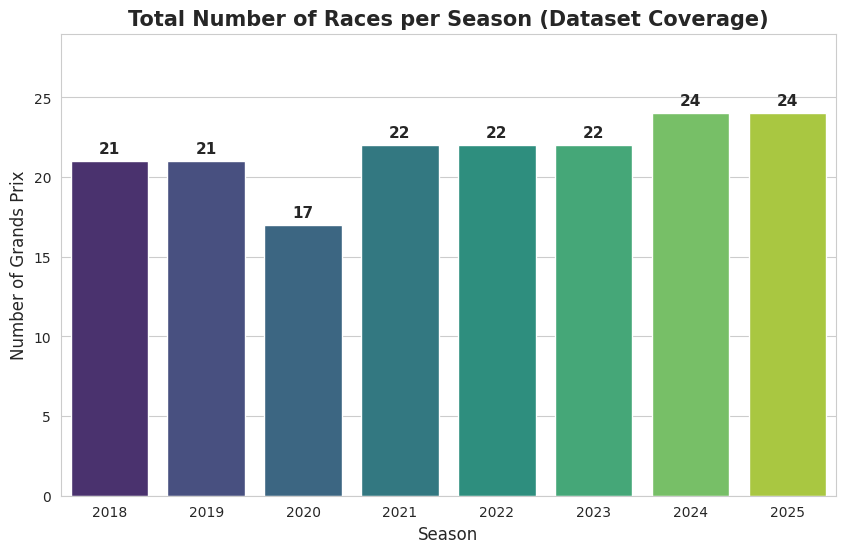

--- Race Count Summary ---
 Season  Race_Count
   2018          21
   2019          21
   2020          17
   2021          22
   2022          22
   2023          22
   2024          24
   2025          24


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data to find unique races per season
# We drop duplicates so we only count each race once, not once per driver/lap
races_count = df.drop_duplicates(subset=['Season', 'Round']).groupby('Season').size().reset_index(name='Race_Count')

# 2. Create the Bar Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Using a professional "F1" style color palette
ax = sns.barplot(x='Season', y='Race_Count', data=races_count, palette='viridis')

# 3. Add labels and aesthetics
plt.title('Total Number of Races per Season (Dataset Coverage)', fontsize=15, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Grands Prix', fontsize=12)
plt.ylim(0, races_count['Race_Count'].max() + 5) # Give some space at the top

# Add the actual count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.show()

# Print a quick summary table
print("--- Race Count Summary ---")
print(races_count.to_string(index=False))

In [1]:
import pandas as pd
import numpy as np

# 1. SETUP
df = df.sort_values(['Season', 'Round', 'DriverNumber', 'LapNumber'])
df['TrackStatus'] = df['TrackStatus_Code'].astype(str).str.replace('.0', '', regex=False)

# 2. DEFINE STATES
# Green = Status '1'
# Severe Incident = Status '4' (SC) or '6' (VSC)
df['Is_Green'] = df['TrackStatus'] == '1'
df['Is_Severe'] = df['TrackStatus'].isin(['4', '6'])

# 3. IDENTIFY THE "LAST GREEN LAP"
# We want a lap that is:
#   A. Currently Green
#   B. The NEXT lap is NOT Green (Yellow, VSC, SC, Red Flag, etc.)
#   This identifies the exact moment the "Green Flag Stint" ends.
df['Next_Lap_Is_Green'] = df.groupby(['Season', 'Round', 'DriverNumber'])['Is_Green'].shift(-1).fillna(True)
df['Is_Last_Green_Lap'] = (df['Is_Green'] == True) & (df['Next_Lap_Is_Green'] == False)

# 4. CHECK FOR ESCALATION (The Crystal Ball)
# We look ahead 5 laps. Does a "Severe Incident" (SC/VSC) appear?
# This handles the Yellow Flag bridge: Green -> Yellow -> SC.
# The Green lap sees the SC coming in lap+2 or lap+3.

# Look ahead 5 laps for any severe incident
df['Future_Severe_Incident'] = False
for i in range(1, 6):
    future_severe = df.groupby(['Season', 'Round', 'DriverNumber'])['Is_Severe'].shift(-i).fillna(False)
    df['Future_Severe_Incident'] = df['Future_Severe_Incident'] | future_severe

# 5. DEFINE FINAL TARGET
# Target = It is the Last Green Lap AND it leads to a Severe Incident
df['Target_Root_Cause'] = (df['Is_Last_Green_Lap'] == True) & (df['Future_Severe_Incident'] == True)
df['Target_Root_Cause'] = df['Target_Root_Cause'].astype(int)

# 6. VERIFICATION
print("--- Target Distribution (Last Green Lap Logic) ---")
print(df['Target_Root_Cause'].value_counts())

# --- PROOF: Green -> Yellow -> SC Chain ---
# We want to find a spot where:
# Lap T:   Green (Target=1)
# Lap T+1: Yellow (Target=0)
# Lap T+2: SC (Target=0)

# Find rows where we have a target, but the IMMEDIATE next lap is NOT Severe (so likely Yellow)
complex_mask = (df['Target_Root_Cause'] == 1) & \
               (df.groupby(['Season', 'Round', 'DriverNumber'])['Is_Severe'].shift(-1) == False)

if complex_mask.sum() > 0:
    print("\n--- FOUND COMPLEX CHAIN (Green -> Yellow -> SC) ---")
    sample_idx = df[complex_mask].index[0]
    sample_row = df.loc[sample_idx]

    # Show context: Target Lap + Next 4 Laps
    subset = df[
        (df['Season'] == sample_row['Season']) &
        (df['Round'] == sample_row['Round']) &
        (df['DriverNumber'] == sample_row['DriverNumber']) &
        (df['LapNumber'].between(sample_row['LapNumber'], sample_row['LapNumber'] + 4))
    ]
    print(subset[['LapNumber', 'TrackStatus', 'Is_Green', 'Target_Root_Cause']])
else:
    print("No Green->Yellow->SC chains found in head (check full dataset).")

NameError: name 'df' is not defined

In [15]:
import pandas as pd

# 1. SETUP: Fix the Boolean Warning
# We act explicitly to avoid the FutureWarning
pd.set_option('future.no_silent_downcasting', True)

# 2. DEFINE NEUTRALIZATION (SC + VSC)
# Status 4 = SC, Status 6 = VSC
df['Is_Neutralized'] = df['TrackStatus'].isin(['4', '6'])

# 3. DETECT THE START (The "Rising Edge") - CORRECTED GROUPBY
# We MUST include 'DriverNumber' so we compare the same car's timeline.
# shift(1) moves the previous lap's status to the current row.
df['Prev_Lap_Status'] = df.groupby(['Season', 'Round', 'DriverNumber'])['Is_Neutralized'] \
                          .shift(1).fillna(False).infer_objects(copy=False)

# A lap is a "Start" if: Current is True AND Previous was False
df['Incident_Start_Lap'] = (df['Is_Neutralized'] == True) & (df['Prev_Lap_Status'] == False)

# 4. VERIFY WITH A REAL CRASH (Not Lap 1)
# Let's look for the 2024 Saudi Arabia GP (Round 2)
# Lance Stroll crashed on Lap 6/7, causing a Safety Car.
print("--- Verification: Looking for the SC Trigger in Saudi 2024 ---")
check = df[
    (df['Season'] == 2024) &
    (df['Round'] == 2) &
    (df['DriverNumber'] == 1) # Look at Max Verstappen only to keep output clean
][['LapNumber', 'TrackStatus', 'Is_Neutralized', 'Incident_Start_Lap']]

# Filter to show only the laps around the crash
print(check[(check['LapNumber'] >= 5) & (check['LapNumber'] <= 10)])

--- Verification: Looking for the SC Trigger in Saudi 2024 ---
       LapNumber TrackStatus  Is_Neutralized  Incident_Start_Lap
95218        5.0           1           False               False
95237        6.0           1           False               False
95256        7.0           1           False               False
95274        8.0           4            True                True
95293        9.0           4            True               False
95311       10.0           1           False               False


Aggregating data to Lap Level (Race State)...
Generating justification graphs...


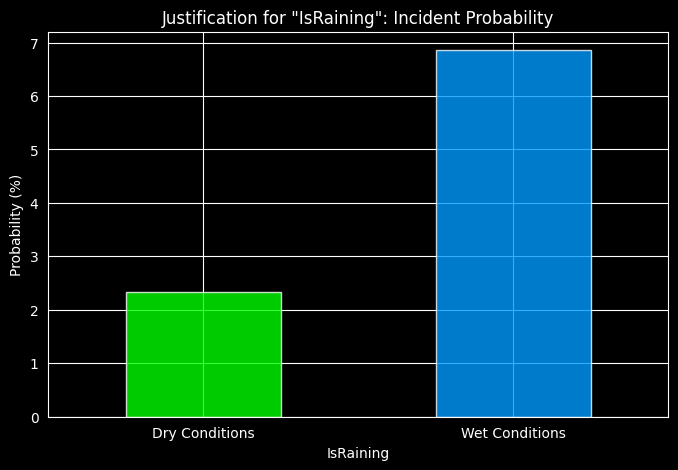

/tmp/ipykernel_20308/1232258266.py:134: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


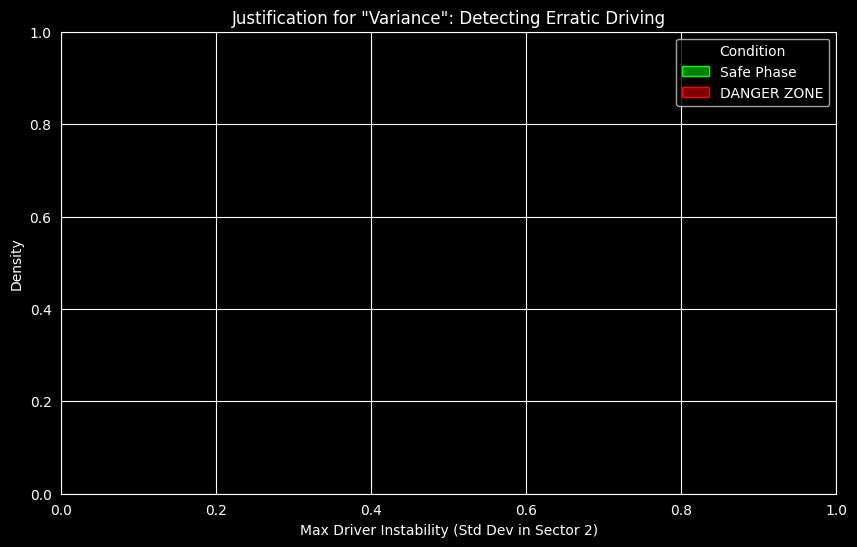

/tmp/ipykernel_20308/1232258266.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


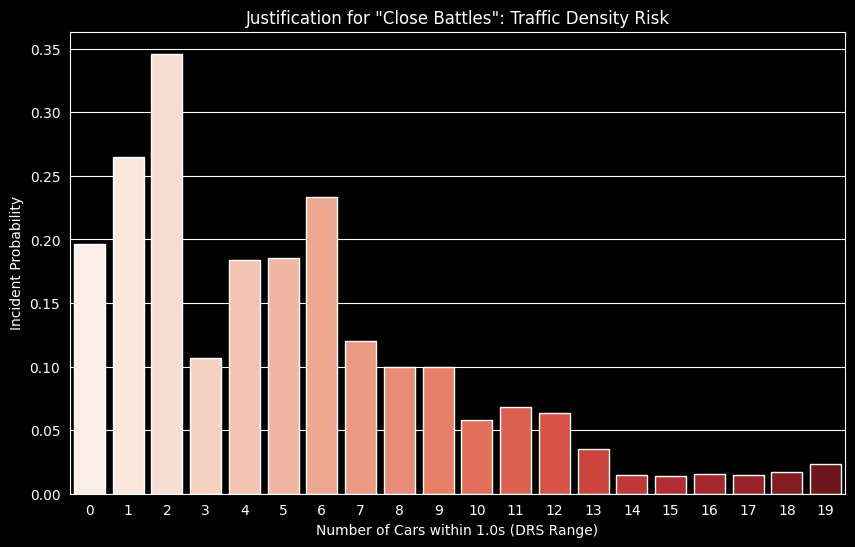

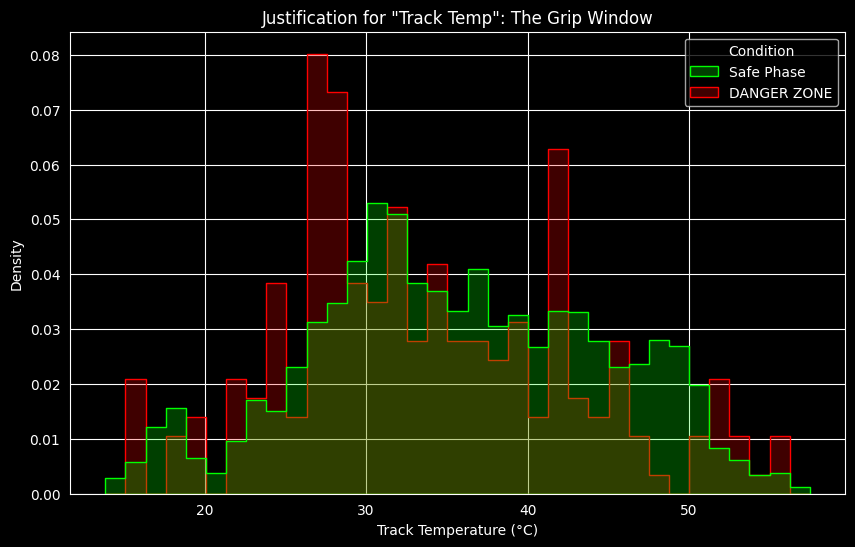

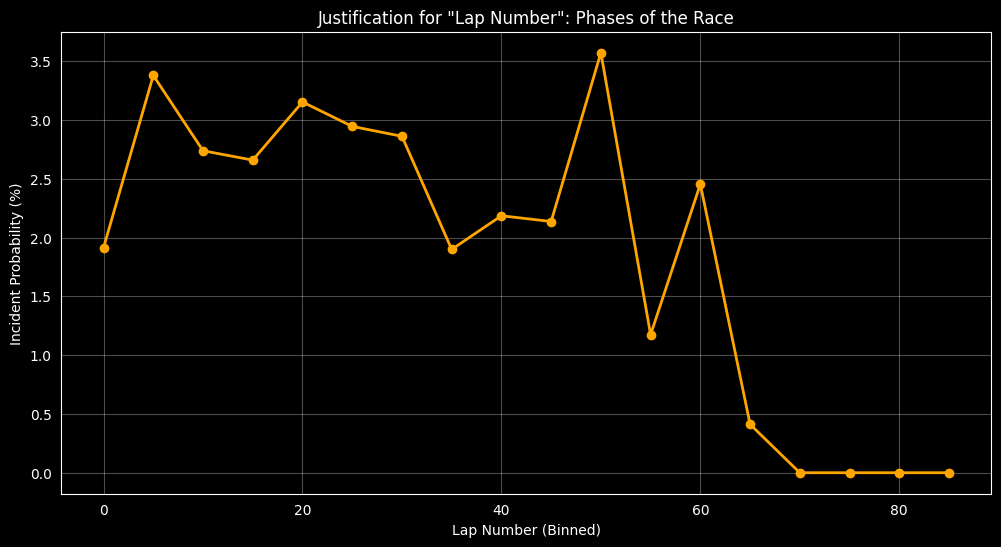

/tmp/ipykernel_20308/1232258266.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


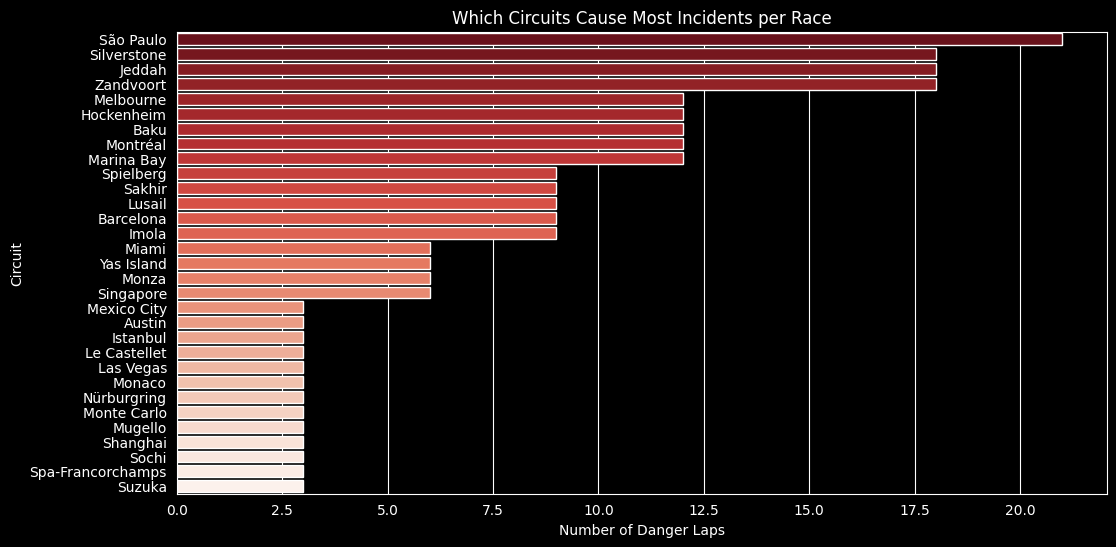

EDA Complete. These patterns justify the feature selection for the XGBoost model.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD & PREPARE RAW DATA
# ==========================================
# Ensure you point this to your actual file path
df = pd.read_csv('csv_data/f1_race_data_v2.csv')

# Clean Track Status
df['TrackStatus'] = df['TrackStatus'].astype(str).str.replace('.0', '', regex=False)

def find_best_match(possible_names):
    for name in possible_names:
        matches = [c for c in df.columns if name.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

t_col = find_best_match(['LapTime', 'SessionTime', 'Time'])
s2_col = find_best_match(['Sector2Time', 'S2Time', 'Sector2'])
circuit_col = find_best_match(['Circuit', 'EventName', 'Location'])

# ==========================================
# 2. FEATURE ENGINEERING (THE "WHY")
# ==========================================
def aggregate_race_state(group):
    # Filter for Green Flag running only (Status '1')
    on_track = group[group['TrackStatus'] == '1'].copy()
    circuit_name = str(group[circuit_col].iloc[0]) if circuit_col else "Unknown"

    if on_track.empty:
        return pd.Series({
            'Circuit': circuit_name,
            'Max_S2_Variance': 0.0, 'Close_Battles': 0,
            'CarsRunning': group['DriverNumber'].nunique(),
            'IsRaining': 0, 'TrackTemp': 0,
            'TrackStatus': group['TrackStatus'].iloc[0]
        })

    # --- FIX: Ensure we use NUMERIC data for calculations ---
    # Convert columns to numeric, forcing errors to NaN
    s2_numeric = pd.to_numeric(on_track[s2_col], errors='coerce')
    t_numeric = pd.to_numeric(on_track[t_col], errors='coerce')

    # 1. MEASURE INSTABILITY (The "Loose Cannon" Theory)
    # Group the NUMERIC sector times by driver
    driver_s2_std = s2_numeric.groupby(on_track['DriverNumber']).std()
    max_s2_var = driver_s2_std.max()

    # Fill NaN with 0 (happens if a driver only did 1 lap, std cannot be calculated)
    if pd.isna(max_s2_var):
        max_s2_var = 0.0

    # 2. MEASURE TRAFFIC (The "Hornets Nest" Theory)
    t_vals = t_numeric.sort_values()
    gaps = t_vals.diff()
    close_battles = (gaps < 1.0).sum()

    return pd.Series({
        'Circuit': circuit_name,
        'Max_S2_Variance': max_s2_var,
        'Close_Battles': close_battles,
        'CarsRunning': group['DriverNumber'].nunique(),
        'IsRaining': group['Rainfall'].max(),
        'TrackTemp': group['TrackTemp'].mean(),
        'TrackStatus': group['TrackStatus'].iloc[0]
    })

print("Aggregating data to Lap Level (Race State)...")
race_summary = df.groupby(['Season', 'Round', 'LapNumber']).apply(
    aggregate_race_state, include_groups=False
).reset_index()

# ==========================================
# 3. LABELING THE TRUTH (GROUND TRUTH)
# ==========================================
race_summary = race_summary.sort_values(['Season', 'Round', 'LapNumber'])
race_summary['Target'] = 0
race_summary['Is_Potential_Incident'] = (race_summary['TrackStatus'] != '1').astype(int)
race_summary['EventID'] = (
    race_summary['Is_Potential_Incident'] != race_summary['Is_Potential_Incident'].shift()
).cumsum()

# Flag the 3 laps BEFORE a major incident (SC/VSC/Red Flag)
major_events = race_summary[race_summary['TrackStatus'].isin(['3', '4', '5', '6'])]['EventID'].unique()

for event_id in major_events:
    event_data = race_summary[race_summary['EventID'] == event_id]
    incident_start_lap = event_data['LapNumber'].min()
    if incident_start_lap > 3:
        target_laps = [incident_start_lap - 1, incident_start_lap - 2, incident_start_lap - 3]

        race_summary.loc[
            (race_summary['Season'] == event_data['Season'].iloc[0]) &
            (race_summary['Round'] == event_data['Round'].iloc[0]) &
            (race_summary['LapNumber'].isin(target_laps)),
            'Target'
        ] = 1

# Filter for plotting: Only look at Green Flag laps vs Pre-Crash Laps
plot_df = race_summary[race_summary['TrackStatus'] == '1'].copy()
plot_df['Condition'] = plot_df['Target'].map({0: 'Safe Phase', 1: 'DANGER ZONE'})

# Fill any remaining NaNs to prevent plotting errors
plot_df['Max_S2_Variance'] = plot_df['Max_S2_Variance'].fillna(0)

# ==========================================
# 4. THE PROOF (VISUALIZATIONS)
# ==========================================
sns.set_style("darkgrid")
plt.style.use("dark_background")

print("Generating justification graphs...")

# --- GRAPH 1: The Weather Argument ---
plt.figure(figsize=(8, 5))
rain_risk = plot_df.groupby('IsRaining')['Target'].mean() * 100
rain_risk.plot(kind='bar', color=['#00ff00', '#0099ff'], alpha=0.8)
plt.title('Justification for "IsRaining": Incident Probability')
plt.ylabel('Probability (%)')
plt.xticks([0, 1], ['Dry Conditions', 'Wet Conditions'], rotation=0)
plt.show()

# --- GRAPH 2: The Instability Argument ---
plt.figure(figsize=(10, 6))
# Calculate a safe upper limit for the plot
upper_lim = plot_df['Max_S2_Variance'].quantile(0.95)
if pd.isna(upper_lim) or upper_lim == 0:
    upper_lim = 1.0 # Default fallback if data is flat

sns.kdeplot(
    data=plot_df, x='Max_S2_Variance', hue='Condition',
    fill=True, common_norm=False, palette=['#00ff00', '#ff0000'], alpha=0.5
)
plt.title('Justification for "Variance": Detecting Erratic Driving')
plt.xlim(0, upper_lim)
plt.xlabel('Max Driver Instability (Std Dev in Sector 2)')
plt.show()

# --- GRAPH 3: The Traffic Argument ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df, x='Close_Battles', y='Target',
    palette='Reds', errorbar=None
)
plt.title('Justification for "Close Battles": Traffic Density Risk')
plt.xlabel('Number of Cars within 1.0s (DRS Range)')
plt.ylabel('Incident Probability')
plt.show()

# --- GRAPH 4: The Temperature Argument ---
plt.figure(figsize=(10, 6))
sns.histplot(
    data=plot_df, x='TrackTemp', hue='Condition',
    element="step", stat="density", common_norm=False, palette=['#00ff00', '#ff0000']
)
plt.title('Justification for "Track Temp": The Grip Window')
plt.xlabel('Track Temperature (°C)')
plt.show()

# --- GRAPH 5: The Race Pace Argument ---
plot_df['Lap_Bin'] = (plot_df['LapNumber'] // 5) * 5
lap_risk = plot_df.groupby('Lap_Bin')['Target'].mean() * 100

plt.figure(figsize=(12, 6))
lap_risk.plot(kind='line', marker='o', color='orange', linewidth=2)
plt.title('Justification for "Lap Number": Phases of the Race')
plt.xlabel('Lap Number (Binned)')
plt.ylabel('Incident Probability (%)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# GRAPH 6: Incidents per Circuit
# ==========================================
# Count number of danger laps (Target==1) per circuit
incidents_per_circuit = race_summary[race_summary['Target'] == 1].groupby('Circuit')['Target'].count()

# Sort descending to see most dangerous circuits first
incidents_per_circuit = incidents_per_circuit.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=incidents_per_circuit.values,
    y=incidents_per_circuit.index,
    palette='Reds_r'
)
plt.title("Which Circuits Cause Most Incidents per Race")
plt.xlabel("Number of Danger Laps")
plt.ylabel("Circuit")
plt.show()

print("EDA Complete. These patterns justify the feature selection for the XGBoost model.")